# Genetic Algorithm Feature Selection (GbFS)

This notebook implements the Genetic Based Feature Selection (GbFS) method proposed by Halim et al. (2021).

**Objective:** find an optimal subset of features that maximizes accuracy while minimizing feature correlation.

**Fitness Function:**
$$ Fitness = \frac{Accuracy + (1 - Average\_Correlation)}{2} $$

**components:**
1. **GeneticSelector Class**: Encapsulates the GA logic using PyGAD.
2. **Fitness Calculation**: evaluation using Decision Tree accuracy and Pearson correlation.
3. **Execution**: Run GA, select features, and Evaluate final model.

In [9]:
import os
import pandas as pd
import numpy as np
import pygad
import time 
import json
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

In [10]:
# Load and prepare data (same as before)
df = pd.read_csv('processed_cicids2017.csv')
df.dropna(inplace=True)

X = df.drop(columns=['Label'])

# Remove columns with zero variance (constant columns)
# These columns cause division by zero errors in correlation calculation
X = X.loc[:, X.std() > 0]

y = df['Label']
feature_names = X.columns.tolist()

# Split and Scale
# Using a smaller subset for GA evolution to speed up fitness calculation if needed,
# but for 10% sample size, we might use the full training set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features remaining: {len(feature_names)}")
print(f"Training Shape: {X_train_scaled.shape}")

Features remaining: 69
Training Shape: (201663, 69)


In [11]:
# Define fitness function outside the class

# Global variables for data (initialized to None)
X_train_fold = None
X_val_fold = None
y_sub_train_global = None
y_sub_val_global = None

# Global variable for progress bar and metrics tracking
pbar_global = None
history = {'generation': [], 'fitness': [], 'accuracy': [], 'features': []}

def calculate_fitness(ga_instance, solution, solution_idx):
    if X_train_fold is None:
        return 0 

    # Check if no features are selected (avoid empty selection)
    if sum(solution) == 0:
        return 0

    # 1. Identify selected features indices
    selected_indices = [i for i, x in enumerate(solution) if x == 1]
    
    # 2. Calculate Accuracy
    X_train_sel = X_train_fold[:, selected_indices]
    X_val_sel = X_val_fold[:, selected_indices]
    
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train_sel, y_sub_train_global)
    accuracy = clf.score(X_val_sel, y_sub_val_global)
    
    # 3. Calculate Average Correlation
    if len(selected_indices) > 1:
        # Calculate correlation matrix
        # Suppress RuntimeWarnings for division by zero (constant columns in fold)
        with np.errstate(invalid='ignore', divide='ignore'):
            corr_matrix = np.corrcoef(X_val_sel, rowvar=False)

        # Handle potential NaNs/Infs from constant columns
        corr_matrix = np.nan_to_num(corr_matrix)
        
        # Mean absolute off-diagonal correlation
        abs_corr = np.abs(corr_matrix)
        mask = np.triu(np.ones_like(abs_corr, dtype=bool), k=1)
        avg_corr = np.mean(abs_corr[mask]) if np.any(mask) else 0
    else:
        avg_corr = 0 

    # 4. Final Fitness (Combine Acc and Corr)
    fitness = (accuracy + (1 - avg_corr)) / 2
    return fitness

def on_generation_callback(ga_instance):
    global pbar_global, history
    
    # Get best solution of this generation
    solution, fitness, _ = ga_instance.best_solution()
    selected_indices = [i for i, x in enumerate(solution) if x == 1]
    
    # Recalculate pure accuracy for tracking (fitness is mixed)
    if len(selected_indices) > 0:
        X_train_sel = X_train_fold[:, selected_indices]
        X_val_sel = X_val_fold[:, selected_indices]
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_train_sel, y_sub_train_global)
        acc = clf.score(X_val_sel, y_sub_val_global)
    else:
        acc = 0.0

    # Log to history for Pareto plotting later
    history['generation'].append(ga_instance.generations_completed)
    history['fitness'].append(fitness)
    history['accuracy'].append(acc)
    history['features'].append(len(selected_indices))
    
    if pbar_global:
        pbar_global.update(1)
        pbar_global.set_description(f"Gen {ga_instance.generations_completed} - Fit: {fitness:.4f} | Acc: {acc:.4f} | Feat: {len(selected_indices)}")

class GeneticSelector:
    def __init__(self, X_train, y_train, feature_names, pop_size=20, num_generations=10):
        self.X_train = X_train
        self.y_train = y_train
        self.feature_names = feature_names
        self.pop_size = pop_size
        self.num_generations = num_generations
        self.ga_instance = None
        self.training_time = 0
        
        # Optimization: Pre-split the data once
        self.X_sub_train, self.X_sub_val, self.y_sub_train, self.y_sub_val = train_test_split(
            self.X_train, self.y_train, test_size=0.2, random_state=42, stratify=self.y_train
        )

    def run(self):
        # Set global variables
        global X_train_fold, X_val_fold, y_sub_train_global, y_sub_val_global, pbar_global
        X_train_fold = self.X_sub_train
        X_val_fold = self.X_sub_val
        y_sub_train_global = self.y_sub_train
        y_sub_val_global = self.y_sub_val
        num_genes = self.X_train.shape[1]
        pbar_global = tqdm(total=self.num_generations, desc="Evolution Progress", leave=True)
        
        n_jobs = os.cpu_count()
        parallel_processing = ["thread", n_jobs] 

        self.ga_instance = pygad.GA(
            num_generations=self.num_generations,
            num_parents_mating=int(self.pop_size / 2),
            fitness_func=calculate_fitness,
            sol_per_pop=self.pop_size,
            num_genes=num_genes,
            gene_space=[0, 1],
            parent_selection_type="sss",
            keep_parents=1,
            crossover_type="single_point",
            mutation_type="random",
            mutation_percent_genes=10,
            suppress_warnings=True,
            on_generation=on_generation_callback,
            parallel_processing=parallel_processing
        )
        
        print(f"Starting Genetic Algorithm execution using {n_jobs} threads...")
        start_time = time.time() # Start timer
        try:
            self.ga_instance.run()
        except Exception as e:
            print(f"Error: {e}")
            print("Fallback to single-threaded mode.")
            self.ga_instance.parallel_processing = None
            self.ga_instance.run()
        finally:
            end_time = time.time()
            self.training_time = end_time - start_time
            if pbar_global:
                pbar_global.close()
            
        print(f"Genetic Algorithm execution complete. Time taken: {self.training_time:.2f} seconds.")
        
    def get_best_features(self):
        solution, solution_fitness, solution_idx = self.ga_instance.best_solution()
        selected_indices = [i for i, x in enumerate(solution) if x == 1]
        selected_names = [self.feature_names[i] for i in selected_indices]
        return selected_indices, selected_names, solution_fitness, self.training_time

In [12]:
# Execute GA
selector = GeneticSelector(X_train_scaled, y_train, feature_names, pop_size=20, num_generations=10)
selector.run()

Evolution Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Starting Genetic Algorithm execution using 12 threads...
Genetic Algorithm execution complete. Time taken: 241.46 seconds.


In [13]:
# Retrieve Results
best_indices, best_features, best_fitness, ga_runtime = selector.get_best_features()

print(f"Best Solution Fitness: {best_fitness:.4f}")
print(f"Number of Selected Features: {len(best_features)}")
print(f"Computational Cost (GA Runtime): {ga_runtime:.4f} seconds")
print("Selected Features:", best_features)

Best Solution Fitness: 0.9596
Number of Selected Features: 31
Computational Cost (GA Runtime): 241.4579 seconds
Selected Features: ['Destination Port', 'Total Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Min', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Std', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Mean', 'FIN Flag Count', 'RST Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'Active Max', 'Active Min', 'Idle Max']



Training Final Classifier on Selected Features...

Classification Report (GA Selected Features):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41901
           1       0.99      0.99      0.99      8515

    accuracy                           1.00     50416
   macro avg       1.00      1.00      1.00     50416
weighted avg       1.00      1.00      1.00     50416

=== GA Final Metrics ===
Accuracy: 0.997600
Precision: 0.997599
Recall: 0.997600
F1-Score: 0.997599
Detection Rate (TPR): 0.992249
False Positive Rate (FPR): 0.001313
Feature Count: 31.000000
Runtime (s): 241.457851


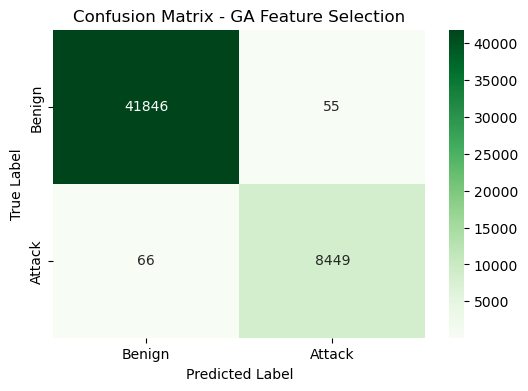

In [14]:
# Train Final Model with Selected Features
print("\nTraining Final Classifier on Selected Features...")

# Filter Train/Test sets to only selected columns (by index)
X_train_selected = X_train_scaled[:, best_indices]
X_test_selected = X_test_scaled[:, best_indices]

# Using Decision Tree (Entropy) as refined benchmark
final_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
final_model.fit(X_train_selected, y_train)

y_pred_ga = final_model.predict(X_test_selected)

# Extended Metrics Evaluation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ga).ravel()

acc_ga = accuracy_score(y_test, y_pred_ga)
prec_ga = precision_score(y_test, y_pred_ga, average='weighted')
rec_ga = recall_score(y_test, y_pred_ga, average='weighted')
f1_ga = f1_score(y_test, y_pred_ga, average='weighted')

detection_rate_ga = tp / (tp + fn)
false_positive_rate_ga = fp / (fp + tn)

print("\nClassification Report (GA Selected Features):")
print(classification_report(y_test, y_pred_ga))

# Print Metrics Dictionary
ga_final_metrics = {
    'Accuracy': acc_ga,
    'Precision': prec_ga,
    'Recall': rec_ga,
    'F1-Score': f1_ga,
    'Detection Rate (TPR)': detection_rate_ga,
    'False Positive Rate (FPR)': false_positive_rate_ga,
    'Feature Count': len(best_features),
    'Runtime (s)': ga_runtime
}

print("=== GA Final Metrics ===")
for k, v in ga_final_metrics.items():
    print(f"{k}: {v:.6f}")

conf_matrix_ga = confusion_matrix(y_test, y_pred_ga)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_ga, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix - GA Feature Selection')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

c:\Users\user\anaconda3\Lib\site-packages\pygad\visualize\plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


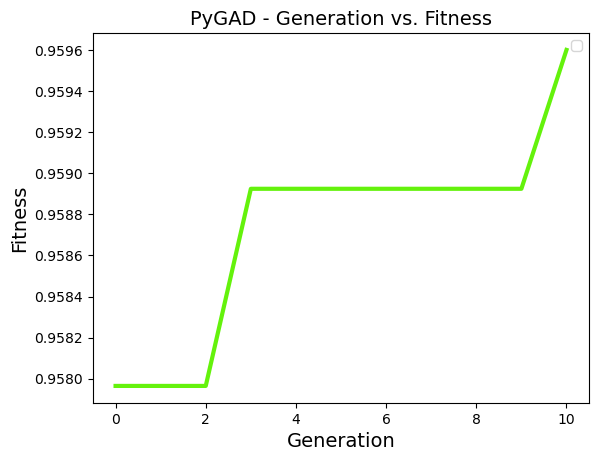

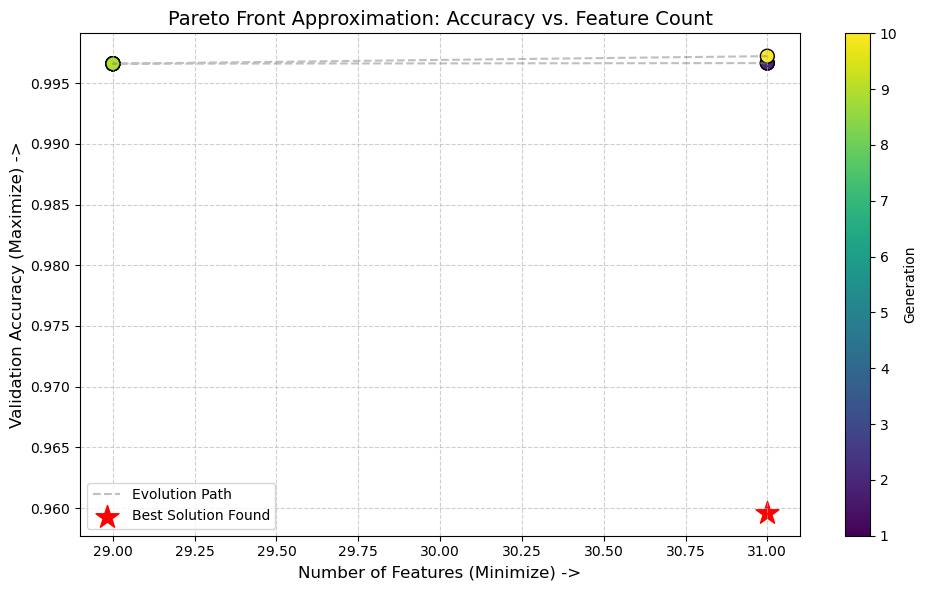

In [15]:
# Plot GA Fitness Evolution
selector.ga_instance.plot_fitness()

# --- Pareto Front Visualization ---
# Plotting the trade-off between Accuracy and Number of Features across generations
plt.figure(figsize=(10, 6))

# Evolution Path
plt.plot(history['features'], history['accuracy'], color='gray', linestyle='--', alpha=0.5, label='Evolution Path')
# Points (Generations)
plt.scatter(history['features'], history['accuracy'], c=history['generation'], cmap='viridis', s=100, edgecolors='black')

plt.colorbar(label='Generation')
plt.title('Pareto Front Approximation: Accuracy vs. Feature Count', fontsize=14)
plt.xlabel('Number of Features (Minimize) ->', fontsize=12)
plt.ylabel('Validation Accuracy (Maximize) ->', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight Best Solution
plt.scatter([len(best_features)], [best_fitness], color='red', marker='*', s=300, label='Best Solution Found')

plt.legend()
plt.tight_layout()
plt.show()

GA metrics saved to results/ga_metrics.json

=== Model Comparison Results ===
               Baseline (All Features)  GA Selected Features
Accuracy                      0.998155              0.997600
Precision                     0.998156              0.997599
Recall                        0.998155              0.997600
F1-Score                      0.998155              0.997599
Feature Count                77.000000             31.000000


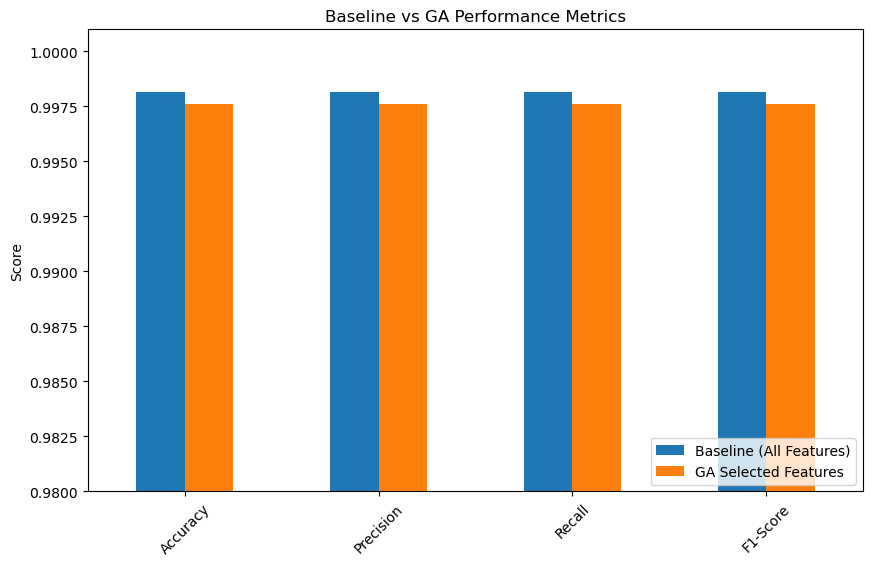


Feature Reduction: 77 -> 31
Reduction Percentage: 59.74%


In [16]:
# --- COMPARISON WITH BASELINE ---
try:
    with open('results/baseline_metrics.json', 'r') as f:
        baseline_metrics = json.load(f)
except FileNotFoundError:
    print("Warning: baseline_metrics.json not found. Using default placeholder values.")
    baseline_metrics = {
        'Accuracy': 0.9982,
        'Precision': 0.9982,
        'Recall': 0.9982,
        'F1-Score': 0.9982,
        'Feature Count': 77
    }

metrics_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Feature Count']

# Ensure keys exist (or map them if names differ slightly)
ga_metrics = {
    'Method': 'Genetic Algorithm (GA)',
    'Accuracy': acc_ga,
    'Precision': prec_ga,
    'Recall': rec_ga,
    'F1-Score': f1_ga,
    'Detection Rate (TPR)': detection_rate_ga,
    'False Positive Rate (FPR)': false_positive_rate_ga,
    'Feature Count': len(best_features),
    'Runtime (s)': ga_runtime
}

# --- SAVE GA METRICS to JSON ---
ga_metrics_path = 'results/ga_metrics.json'
with open(ga_metrics_path, 'w') as f:
    json.dump(ga_metrics, f, indent=4)
print(f"GA metrics saved to {ga_metrics_path}")

# Create Comparison DataFrame
# Filter only the keys we want to compare
baseline_filtered = {k: baseline_metrics.get(k, 0) for k in metrics_keys}
ga_filtered = {k: ga_metrics.get(k, 0) for k in metrics_keys}

results_df = pd.DataFrame([baseline_filtered, ga_filtered], index=['Baseline (All Features)', 'GA Selected Features'])

print("\n=== Model Comparison Results ===")
print(results_df.T)

# Visualization of Improvement/Trade-off
results_without_count = results_df.drop('Feature Count', axis=1)

results_without_count.T.plot(kind='bar', figsize=(10, 6))
plt.title('Baseline vs GA Performance Metrics')
plt.ylabel('Score')
plt.ylim(0.98, 1.001) # Zoom in to see small differences
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()

print(f"\nFeature Reduction: {baseline_metrics['Feature Count']} -> {ga_metrics['Feature Count']}")
print(f"Reduction Percentage: {((baseline_metrics['Feature Count'] - ga_metrics['Feature Count'])/baseline_metrics['Feature Count'])*100:.2f}%")